In [1]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots
using Measures

Simulate the dynamics of the spinful Hubbard model on a 2D lattice of $N_x \times N_y$ spinful sites. The Hamiltonian is
$$\hat{H}=-t \sum_{\langle i,j\rangle, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{j, \sigma}+\hat{c}_{j, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}$$

In [3]:
# a useful utility function
function propagateandrescale!(circuit, prop_cache::MajoranaPropagation.VectorMajoranaPropagationCache, params; min_abs_coeff=1e-10)
    @assert length(circuit) == length(params)
    for (gate, param) in zip(circuit, params)
        prop_cache = propagate!(gate, prop_cache, param; min_abs_coeff)
        coeffs = coefficients(prop_cache)
        # the first coefficient is always the identity
        coeffs ./= coeffs[1]
    end

    return prop_cache
end

propagateandrescale! (generic function with 1 method)

In [4]:
N_x = 6
N_y = 1
N_spinful_sites = N_x * N_y
t = 1.0
U = 8.0

8.0

Get 2D connectivity, and create the circtuit for implementing a single layer of first order Trotterization.

In [5]:
topo = rectangletopology(N_x, N_y)

imag_circ = []
imag_thetas = []

H = MajoranaSum(Float64, N_spinful_sites, true)

dt = 0.02

#up hoppings 
for (i, j) in topo
    push!(imag_circ, ImaginaryFermionicGate(:hopup, [i, j]))
    push!(imag_thetas, t * dt)
    H += MajoranaSum(N_spinful_sites, :hopup, [i, j]) * (-t)
end

#down hoppings 
for (i, j) in topo
    push!(imag_circ, ImaginaryFermionicGate(:hopdn, [i, j]))
    push!(imag_thetas, t * dt)
    H += MajoranaSum(N_spinful_sites, :hopdn, [i, j]) * (-t)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(imag_circ, ImaginaryFermionicGate(:nupndn, [i]))
    push!(imag_thetas, - U * dt)
    # t1 = MajoranaSum(N_spinful_sites, :nup, [i])
    # t2 = MajoranaSum(N_spinful_sites, :ndn, [i])
    # MajoranaPropagation.pop_id!(t1)
    # MajoranaPropagation.pop_id!(t2)
    # H_term = t1 * t2 * U
    # H += H_term
    H += MajoranaSum(N_spinful_sites, :nupndn, [i]) * U
end

Backpropagate $n_{2,\uparrow}$, the up density on site 2

In [8]:
target_beta = 2
n_layers = Int(round(target_beta / dt))

min_abs_coeff = 5e-4

obs = MajoranaSum(N_spinful_sites, true, Dict(getinttype(N_spinful_sites*2)(0) => 1.0))
obs = VectorMajoranaSum(obs)
@show obs 

prop_cache = PropagationCache(obs)

res = zeros(n_layers+1)
#res[1] = scalarproduct(H, prop_cache)
length_res = zeros(Int, n_layers+1)
length_res[1] = length(prop_cache)

for l in 1:n_layers
    prop_cache = propagateandrescale!(imag_circ, prop_cache, imag_thetas; min_abs_coeff)
    #res[l+1] = _scalarproduct(H, prop_cache)
    length_res[l+1] = length(prop_cache)
end 
prop_cache

obs = VectorMajoranaSum with 1 term:
1.0 * 000000000000000000000000



MajoranaPropagation.VectorMajoranaPropagationCache{VectorMajoranaSum{Vector{PauliPropagation.UInt24}, Vector{Float64}}, Vector{Bool}, Vector{Int64}}(VectorMajoranaSum with 322539 terms:
1.0 * 000000000000000000000000
-0.4377060315043337 * 110000000000000000000000
-0.421753436854835 * 001100000000000000000000
0.13452285859318996 * 111100000000000000000000
-0.3673350841880548 * 010010000000000000000000
-0.3380498069307823 * 011110000000000000000000
0.36715679553915975 * 100001000000000000000000
0.33850942021312064 * 101101000000000000000000
-0.4430373249803844 * 000011000000000000000000
-0.021001734926538965 * 110011000000000000000000
-0.12511970328135924 * 001111000000000000000000
-0.2908644958261639 * 111111000000000000000000
-0.3750768689464352 * 000100100000000000000000
-0.34739844945919984 * 110100100000000000000000
0.008868215881224549 * 101010100000000000000000
0.018407444676366982 * 010110100000000000000000
0.004803144818078785 * 011001100000000000000000
-0.012122770911708356 * 1

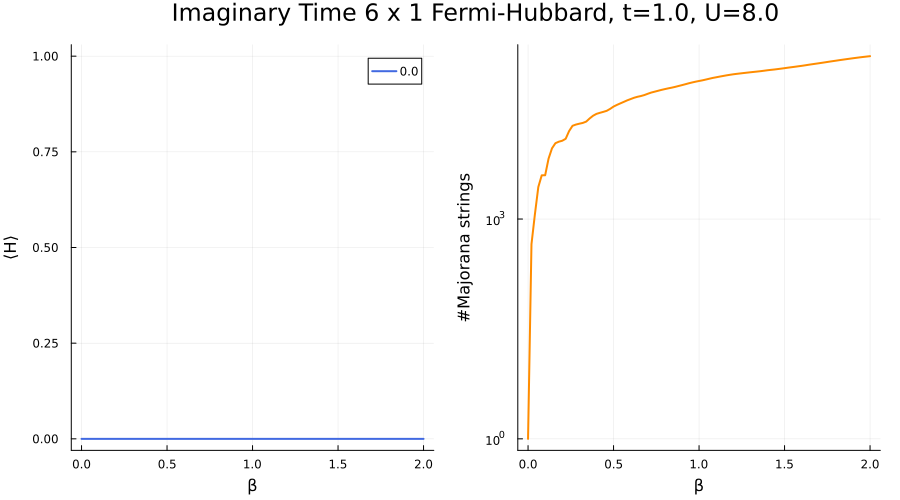

In [9]:
p_res = plot(dt*(0:n_layers)./ t, res, label=round(res[end], digits=3), xlabel="β", ylabel="⟨H⟩", lw=2, color=:royalblue)
p_length = plot(dt*(0:n_layers)./ t, length_res, label="", xlabel="β", ylabel="#Majorana strings", yscale=:log10, lw=2, color=:darkorange)    

plot(p_res, p_length, layout=(1,2), size=(900,500), margin=3mm, suptitle="Imaginary Time $N_x x $N_y Fermi-Hubbard, t=$t, U=$U")